In [ ]:
import tomobase 
import tomondt
import pathlib
import os 
import stackview

#Rod-D jumping-mountain-36 or olive-darkness-63
#Cage-D sage-forest-34
file_name = 'AuAg_350_byIndex_normalized_rot90_v2_dipster'
instance_name = 'twilight-shape-19-alltime'
#ref_path = pathlib.Path(os.path.join(r'\\ematbyname\emat\TimC\DIPSTER-PublicationData\PData\Volumes128', file_name+'.vmf'))
dip_path = pathlib.Path(os.path.join(r'\\ematbyname\emat\Adrien\DIPSTER\ResultsDIPSTER', file_name+'_'+instance_name+'.vmf'))

print(dip_path)
# ref = tomondt.read_vmf(ref_path)
dip = tomondt.read_vmf(str(dip_path))




In [ ]:

from tomobase.data import Sinogram, Volume
from tomobase.processes import project
import copy

sino_path = pathlib.Path(os.path.join(r'\\ematbyname\emat\TimC\DIPSTER-PublicationData\PData\TiltSeries128', file_name+'.mat'))
sino_ref = Sinogram.from_file(sino_path)
sino_dip = copy.deepcopy(sino_ref)

print(sino_ref.angles)
for i, t in enumerate(dip.times):
    sino_dip.data[i,:,:] = project(Volume(dip.read_record(t).transpose(2,1,0)), [sino_ref.angles[i]]).data

sino_ref = tomobase.processes.background_subtract_median(sino_ref)
sino_dip = tomobase.processes.background_subtract_median(sino_dip)

sino_dip = tomobase.processes.normalize(sino_dip)
stackview.side_by_side(sino_ref.data, sino_dip.data)

In [ ]:
stackview.side_by_side(sino_ref.data, sino_dip.data)

In [24]:
# convert_to_vmf
from tomobase.data import Volume
import pathlib
import os

from skimage.metrics import structural_similarity as ssim
from skimage.filters import threshold_otsu
from scipy.ndimage import binary_dilation
import numpy as np
from tomobase import processes
import stackview
import copy

min =10000
max = -10000
for t in dip.times:

    #vol_ref = ref.read_record(t)
    #thresh = threshold_otsu(vol_ref)
    #mask = np.zeros_like(vol_ref)
    #mask[vol_ref>=thresh] = 1.0
    #mask = binary_dilation(mask, iterations=4)

    vol = dip.read_record(t).copy()
    #thresh = threshold_otsu(vol)
    #vol = vol[~mask]

    if np.min(vol) < min:
        min = np.min(vol)
    if np.max(vol) > max:
        max = np.max(vol)


for t in dip.times:
    vol_dip = dip.read_record(t).copy() #.transpose(0,2,1)
    #vol_ref = ref.read_record(t)

def normalize_volume(vol, min, max):
    vol = (vol - min) / (max - min)
    return vol

def rmse(vol1, vol2):
    return np.sqrt(np.mean((vol1 - vol2) ** 2))*100

vol_dip = normalize_volume(vol_dip, min, max)
#vol_ref = normalize_volume(vol_ref, min, max)

print(max, min)
#stackview.side_by_side(vol_ref, vol_dip)

1.2450387477874756 -0.13755668699741364


In [ ]:

vol_dip = dip.read_record(t).transpose(2,0,1).copy() #0,2,1
vol_ref = ref.read_record(t)
stackview.side_by_side(vol_dip, vol_ref)

In [ ]:
# convert_to_vmf
from tomobase.data import Volume
import pathlib
import os

from skimage.metrics import structural_similarity as ssim
from skimage.filters import threshold_otsu
from scipy.ndimage import binary_dilation
import numpy as np
from tomobase import processes
import stackview
import copy

rec_path = pathlib.Path(r'\\ematbyname\emat\TimC\DIPSTER-PublicationData\Finalized_Samples\Volumes(AMIRA)\Cage-D_SIRT30_win30')

for i in range(1, 100):
    t = dip.times[i]
    vol = Volume.from_file(os.path.join(rec_path, f'{i} data.rec'))

    vol_dip = dip.read_record(t).transpose(2,0,1).copy()
    vol_ref = ref.read_record(t)

    thresh = threshold_otsu(vol_ref)
    mask = np.zeros_like(vol_ref)
    mask[vol_ref>=thresh] = 1.0
    mask = binary_dilation(mask, iterations=4)


    vol_dip = normalize_volume(vol_dip, min, max)
    vol_dip[~mask] = 0
    vol.data[~mask]= 0

    ssim_index = ssim(vol_ref, vol_dip, data_range= vol_ref.max() - vol_ref.min())
    ssim_rec = ssim(vol_ref, vol.data, data_range = vol_ref.max() - vol_ref.min() )
    rmse_value = rmse(vol_ref, vol_dip)
    rmse_rec = rmse(vol_ref, vol.data)
    
    print(f'{t}, {ssim_index}, {rmse_value}, {ssim_rec}, {rmse_rec},')
stackview.side_by_side(vol_ref, vol_dip)


In [ ]:
import shutil
import mrcz

folder = os.path.join(r'\\ematbyname\emat\TimC\DIPSTER-PublicationData\PData\DIP128\normalized2_mof_128_wendys-knows-all-28_rec')

if os.path.exists(folder):
    shutil.rmtree(folder)

os.mkdir(folder)
i = 0
for time in dip.times:
    vol = dip.read_record(time).transpose(1,0,2)
    vol = normalize_volume(vol, min, max)
    mrcz.writeMRC(vol, os.path.join(folder, str(i)+'data.rec'), pixelsize=[1/1280,1/1280,1/1280], pixelunits='nm')
    i+=1

In [ ]:
from skimage.metrics import structural_similarity as ssim
from skimage.filters import threshold_otsu

import numpy as np
from tomobase import processes
import stackview
import copy

threshold = threshold_otsu(vol_dip)

for t in dip.times:
    vol_dip = dip.read_record(t).transpose(0,2,1).copy()
    vol_ref = ref.read_record(t)

    vol_dip2 = vol_dip.copy()
    vol_dip = np.zeros_like(vol_dip2)

    cv = 42
    vol_dip[cv:-cv, cv:-cv, cv:-cv] = vol_dip2[cv:-cv, cv:-cv, cv:-cv]
    

    vol_dip = normalize_volume(vol_dip, min, max)
    vol_dip[vol_dip < threshold] = 0

    ssim_index = ssim(vol_ref, vol_dip, data_range= vol_dip.max() - vol_dip.min())
    rmse_value = rmse(vol_ref, vol_dip)
    print(f'{t}, {ssim_index}, {rmse_value}')
stackview.side_by_side(vol_ref, vol_dip)

In [ ]:
from skimage.metrics import structural_similarity as ssim
from skimage.filters import threshold_otsu
from scipy.ndimage import binary_dilation
import numpy as np
from tomobase import processes
import stackview
import copy

threshold = threshold_otsu(sino_ref.data)
mask = np.zeros_like(sino_ref.data)
mask[sino_ref.data >= threshold] = 1

mask = binary_dilation(mask, iterations=4)

for i, t in enumerate(dip.times):
    cv = 42
    masked_sino_ref = copy.deepcopy(sino_ref)
    masked_sino_dip = copy.deepcopy(sino_dip)

    #masked_sino_dip.data= np.zeros_like(masked_sino_dip.data)
    #masked_sino_ref.data = np.zeros_like(masked_sino_ref.data)


    #masked_sino_dip[cv:-cv, cv:-cv, cv:-cv] = vol_dip2[cv:-cv, cv:-cv, cv:-cv]

    masked_sino_dip.data[~mask] = 0
    masked_sino_ref.data[~mask] = 0


    ssim_index = ssim(masked_sino_ref.data[i,:,:], masked_sino_dip.data[i,:,:], data_range= masked_sino_dip.data.max() - masked_sino_dip.data.min())
    rmse_value = rmse(masked_sino_ref.data[i,:,:], masked_sino_dip.data[i,:,:])
    print(f'{t}, {sino_ref.angles[i]}, {ssim_index}, {rmse_value}')
stackview.side_by_side(sino_ref.data, sino_dip.data)

In [ ]:
import numpy as np
import scipy.ndimage as ndi

def surface_area_volume(vol, threshold=None):
    # Build a binary object mask
    if threshold is None:
        obj = vol.astype(bool)   # assumes already binary/nonzero = object
    else:
        obj = vol > threshold
        cv = 30
        obj2 = np.zeros_like(obj, dtype=bool)
        obj2[cv:-cv, cv:-cv, cv:-cv] = obj[cv:-cv, cv:-cv, cv:-cv]
        obj = obj2

    volume = int(obj.sum())
    if volume == 0:
        return 0.0, 0, 0, 0

    # 6-connectivity is common for voxel surface
    structure = ndi.generate_binary_structure(3, 1)  # 3D, 6-neighborhood
    eroded = ndi.binary_erosion(obj, structure=structure, border_value=0)

    surface = obj & (~eroded)
    sa = int(surface.sum())  # "surface voxels", not physical area

    return sa / volume, sa, volume, obj


vol_dip = Volume.from_file(os.path.join(rec_path, f'{i} data.rec'))
vol_dip = vol_dip.data
#vol_ref = ref.read_record(dip.times[0]).copy()
thr = threshold_otsu(vol_dip)
# thr_ref = threshold_otsu(vol_ref)
iters = 0
limit = 120
for i in range(100):
    vol_dip = Volume.from_file(os.path.join(rec_path, f'{i} data.rec'))
    vol_dip= vol_dip.data
    #vol_ref = ref.read_record(t).copy()

    #vol_dip = normalize_volume(vol_dip, min, max)

    # compute threshold per-volume *after* normalization, or use a fixed threshold in normalized units
    thr = threshold_otsu(vol_dip)
    sa_vol_dip, sa_dip, vol_dip_count, obj_dip = surface_area_volume(vol_dip, threshold=thr)

    # if vol_ref is not binary, decide thresholding strategy for ref too
    #sa_vol_ref, sa_ref, vol_ref_count, obj_ref = surface_area_volume(vol_ref, threshold=thr_ref)

    #error = abs(sa_vol_dip - sa_vol_ref)
    #error_percent = error / sa_vol_ref * 100 if sa_vol_ref != 0 else 0.0
    #print(t, sa_vol_ref, sa_vol_dip, error, error_percent, sa_ref, vol_ref_count)
    print(t, sa_vol_dip, sa_dip, vol_dip_count)
    if iters == limit:
        break 
    iters += 1
#stackview.side_by_side(obj_ref, obj_dip)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
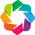

:Overlay
   .Curve.T_equals_0_full_stop_0                  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_010101010091602802 :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_020202020183205605 :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_03030303120613098  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_04040404036641121  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_05050504952669144  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_06060606241226196  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_07070706784725189  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_08080808073282242  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_09090909361839294  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_10101009905338287  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_1111111119389534   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_12121212482452393  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_13131313025951385  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_14141413569450378  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_1515151560306549   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_16161616146564484  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_17171716690063477  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_1818181872367859   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_19191919267177582  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_20202019810676575  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_21212121844291687  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_2222222238779068   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_23232322931289673  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_24242424964904785  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_2525252401828766   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_2626262605190277   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_27272728085517883  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_28282827138900757  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_2929292917251587   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_3030303120613098   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_31313130259513855  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_3232323229312897   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_3333333432674408   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_34343433380126953  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_35353535413742065  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_3636363744735718   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_3737373650074005   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_38383838534355164  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_39393940567970276  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_4040403962135315   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_4141414165496826   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_42424243688583374  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_4343434274196625   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_4444444477558136   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_4545454680919647   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_46464645862579346  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_4747474789619446   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_4848484992980957   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_49494948983192444  :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_5050504803657532   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_5151515007019043   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_5252525210380554   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_5353535413742065   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_5454545617103577   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_5555555820465088   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_5656565427780151   :Curve   [x]   (y)
   .Curve.T_equals_0_full_stop_5757575631141663   :Curve  

In [31]:
import numpy as np
import holoviews as hv
from scipy.signal import find_peaks

hv.extension("bokeh")

curves = []

for t in dip.times:

    vol_dip = dip.read_record(t).copy()
    vol_dip = normalize_volume(vol_dip, min, max)

    hist, edges = np.histogram(vol_dip.ravel(), bins=200)
    centers = (edges[:-1] + edges[1:]) / 2

    curves.append(hv.Curve((centers, hist), label=f"t={t}"))

hv.Overlay(curves)
#vol_dip[vol_dip<0.4]=0
#stackview.slice(vol_dip)

In [32]:
import numpy as np
from scipy.signal import find_peaks

t = 0
vol_dip = dip.read_record(t).copy()
vol_dip = normalize_volume(vol_dip, min, max)

hist, edges = np.histogram(vol_dip.ravel(), bins=200)
centers = 0.5 * (edges[:-1] + edges[1:])

# keep only the region containing the important peaks
mask = (centers > 0.4) & (centers < 1.2)
centers_roi = centers[mask]
hist_roi = hist[mask]

# find peaks in that region
peaks, props = find_peaks(hist_roi, prominence=100)  # tune prominence if needed

# take the two strongest peaks by height
top2 = peaks[np.argsort(hist_roi[peaks])[-2:]]

peak_positions = centers_roi[top2]
peak_heights = hist_roi[top2]

print("Peak positions:", peak_positions)
print("Peak heights:", peak_heights)

Peak positions: [0.91908934 0.64938713]
Peak heights: [11607 13031]


In [53]:

import copy

vol = dip.read_record(0).copy()
vol_ag = copy.deepcopy(vol)
vol_ag = normalize_volume(vol_ag, min, max)
vol_ag[vol_ag<= peak_positions[1]/2] = 0
initial = np.std(vol_ag[vol_ag>0])

vol = dip.read_record(1).copy()
vol_au = copy.deepcopy(vol)
vol_au = normalize_volume(vol_au, min, max)
vol_au[vol_au<= (peak_positions[1]+peak_positions[0])/2] = 0

hetorogenous = np.mean(vol_ag[vol_ag>0])


vol = dip.read_record(1).copy()
vol_final = copy.deepcopy(vol)
vol_final = normalize_volume(vol_final, min, max)
vol_final[vol_final<= peak_positions[1]/2] = 0
vol_final[vol_final > 0 ] = hetorogenous
final = np.std(vol_final[vol_final>0])

print(peak_positions[0], peak_positions[1], hetorogenous)
print(initial, final)
for t in dip.times:
    vol_dip = dip.read_record(t).copy()
    vol = normalize_volume(vol_dip, min, max)
    vol[vol<= peak_positions[1]/2] = 0
    std_val = np.std(vol[vol>0])
    alloying_value = (std_val - initial) / (final - initial)
    alloying_value = alloying_value*100
    print(t, alloying_value, std_val, np.mean(vol))


stackview.slice(vol)

0.9190893370350615 0.6493871271519334 0.7089417264655322
0.15688250155739566 1.1102230246251565e-16
0.0 -0.0 0.15688250155739566 0.15176101598925484
0.010101010091602802 -0.015235626667802298 0.15690640358964006 0.15189894743022847
0.020202020183205605 -0.019268687588779893 0.15691273075650222 0.15202504578146844
0.03030303120613098 -0.040886893284187556 0.156946645938389 0.15214218325407952
0.04040404036641121 -0.07267068058196478 0.15699650913899144 0.15224195658940534
0.05050504952669144 -0.03981642779668203 0.1569449665653539 0.15230601011767214
0.06060606241226196 -0.0014611729275735548 0.15688479388203652 0.15235256357594715
0.07070706784725189 0.03162232001637247 0.1568328916707035 0.15238863631741925
0.08080808073282242 0.06316318707436258 0.15678340956945003 0.15240465775215586
0.09090909361839294 0.0462538427967332 0.15680993737174972 0.15241716744804704
0.10101009905338287 0.07567713083022624 0.15676377738144234 0.15240656491409185
0.1111111119389534 0.08766561150645556 0.15

In [ ]:
import numpy as np
import scipy.ndimage as ndi
import copy

def alloying(vol, initial, final):
    volume = copy.deepcopy(vol) 

    threshold = 0.35
    mask = volume >= threshold
    value = np.std(volume[mask])
    count = np.count_nonzero(mask)
    #print(np.max(volume[mask]), np.min(volume[mask]))
    if np.max(volume[mask]) > 0.988:
        #print('Max exceeded')
        pass
    alloying = (value-initial)/(final- initial)
    #print('Exp', initial, final, value)
    return alloying*100, count, volume



vol_dip = dip.read_record(dip.times[0]).transpose(0,2,1).copy()
vol_dip = normalize_volume(vol_dip, min, max)
#vol_ref = ref.read_record(ref.times[0]).copy()
thr = threshold_otsu(vol_dip)
thr_ref = 0.1

iters = 0
limit = 100

m1 = 0.3
m2 = 1.0

mask = vol_dip >= thr_ref
vol_dip[vol_dip <= thr_ref] = 0

c2 = np.count_nonzero(vol_dip>= m2)
c1 = np.count_nonzero((vol_dip < m2) & (vol_dip >= m1))
initial = np.std(vol_dip[mask])

total=c1+c2
hetorogenous = m1*(c1/total) + m2*(1 - c1/total)
final_vol = copy.deepcopy(vol_dip)
final_vol[mask] = hetorogenous
final = np.std(final_vol[mask])

print(f'c1: {c1}, c2: {c2}, sum: {c1 + c2}, initial: {initial} final: {final}')
for t in dip.times:
    vol_dip = dip.read_record(t).transpose(0,2,1).copy()

    vol_dip = normalize_volume(vol_dip, min, max)
    alloying_dip, count_dip, obj_dip = alloying(vol_dip, initial, final)
    #alloying_ref, count_ref,obj_ref = alloying(vol_ref, initial, final)

    print(t,  alloying_dip, count_dip)
    if iters == limit:
        break 
    iters += 1
stackview.slice(obj_dip)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = normalize_volume(dip.read_record(dip.times[0]).copy(), min, max)
vals = data
hist, edges = np.histogram(vals, bins=400)
centers = 0.5 * (edges[:-1] + edges[1:])

from scipy.ndimage import gaussian_filter1d
hist_smooth = gaussian_filter1d(hist.astype(float), sigma=2)

from scipy.signal import find_peaks

peaks, props = find_peaks(hist_smooth, prominence=0.01 * hist_smooth.max())
print(centers[peaks])
plt.figure(figsize=(6,4))
plt.plot(centers, hist_smooth)
plt.scatter(centers[peaks], hist_smooth[peaks], color="red")
plt.yscale("log")
plt.show()
stackview.orthogonal(data)

In [ ]:
import numpy as np
import scipy.ndimage as ndi
import copy

def alloying(vol, initial, final):
    volume = copy.deepcopy(vol) 

    threshold = 0.17
    mask = volume >= threshold
    value = np.std(volume[mask])
    count = np.count_nonzero(mask)
    #print(np.max(volume[mask]), np.min(volume[mask]))
    if np.max(volume[mask]) > 0.988:
        #print('Max exceeded')
        pass
    alloying = (value-initial)/(final- initial)
    #print('Exp', initial, final, value)
    return alloying*100, count, volume

vol_dip = dip.read_record(dip.times[0]).transpose(0,2,1).copy()
vol_dip = normalize_volume(vol_dip, min, max)
#vol_ref = ref.read_record(ref.times[0]).copy()
thr = threshold_otsu(vol_dip)
thr_ref = 0.17

iters = 0
limit = 100

m1 = 0.35
m2 = 0.75

mask = vol_dip >= thr_ref
#vol_ref[vol_ref <= thr_ref] = 0

c2 = np.count_nonzero(vol_dip>= (m2+m1)/2)
c1 = np.count_nonzero((vol_dip < (m2+m1)/2) & (vol_dip >= (m1/2)))
initial = np.std(vol_dip[mask])

total=c1+c2
hetorogenous = m1*(c1/total) + m2*(1 - c1/total)
final_vol = copy.deepcopy(vol_dip)
final_vol[mask] = hetorogenous
final = np.std(final_vol[mask])

#print(f'c1: {c1}, c2: {c2}, sum: {c1 + c2}, initial: {initial} final: {final}')
for t in dip.times:
    vol_dip = dip.read_record(t).transpose(0,2,1).copy()
    #vol_ref = ref.read_record(t).copy()

    vol_dip = normalize_volume(vol_dip, min, max)
    alloying_dip, count_dip, obj_dip = alloying(vol_dip, initial, final)
    #alloying_ref, count_ref,obj_ref = alloying(vol_ref, initial, final)

    #error = abs(alloying_dip - alloying_ref)
    #error_percent = error / alloying_ref * 100 if alloying_ref != 0 else 0.0
    #print(t, alloying_ref, alloying_dip, error, error_percent, count_dip, count_ref)
    print(t, alloying_dip, count_dip)
    if iters == limit:
        break 
    iters += 1
#stackview.side_by_side( obj_dip)